# Get measured capacity and resistance for each formation protocol

2025/04/30

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from scipy.interpolate import interp1d

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

# Load the Experimental Data

In [2]:
def fetch_file_list(cellid):

    target_dir_arbin = f'{target_dir}/data/raw/from-voltaiq'


    if cellid == 152064:
        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                        ]

        daq_channel = 'Key_CH1'


    elif cellid == 152074: # BASELINE FORMATION (repeat 2)

        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv'
                        ]

        daq_channel = 'Key_CH0'


    elif cellid == 152071: # FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH3'


    elif cellid == 152098: # SUPER FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMFAST_2_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH2'


    return file_arbin_list, daq_channel


In [3]:
def fetch_experimental_data(cellid, max_hours=1000000, to_include_cycling=False):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    if to_include_cycling:
        file_indices_to_include = np.array([1, 2, 3])
    else: # formation only
        file_indices_to_include = np.array([1, 2])

    file_arbin_list, daq_channel = fetch_file_list(cellid)


    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.nan

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out, df_arbin


In [88]:
def run_sim(type, diff_ec, diff_vc, gamma_kappa=3000, dt=5.0, 
            to_follow_current=False, current_vec=np.nan, to_simulate_form_aging=False):
    """
    Run simulation for a given formation type and target EC diffusivity

    Arguments:
    ----------
    type: 'base', 'fast', 'fast+'
    diff_ec: target EC diffusivity, e.g., 4.2e-20 [m2/s]
    diff_vc: target VC diffusivity, e.g., 6.6e-18 [m2/s]

    Returns:
    ----------

    df_sim: DataFrame with simulation results
    """

    cell = cellsim.Cell()
    cell.load_config('params/default.yaml')

    # Update EC diffusivity
    cell.D_SEI11 = diff_ec
    cell.D_SEI21 = diff_ec

    # Update VC diffusivity
    cell.D_SEI12 = diff_vc
    cell.D_SEI22 = diff_vc

    # Update the GAMMA_KAPPA parameter
    cell.GAMMA_KAPPA = gamma_kappa

    if type == 'base':

        sim = cellsim.Simulation(cell, 1000*3600, dt=dt)

        if to_follow_current:
            for k, current in enumerate(current_vec):
                sim.step(k, mode='cc', icc=current, to_debug=False)
                sim.curr_k = k 
        else: 
            sim.run_rest(1, rest_time_hrs=0.5)
            sim.run_chg_cccv(2, 2.5/10, 2.5/20, 4.2)
            sim.run_rest(2, rest_time_hrs=1/6) 
            sim.run_dch_cccv(2, -2.5/10, -2.5/10, 3.0)
            sim.run_rest(2, rest_time_hrs=1/6) 
            sim.run_chg_cccv(3, 2.5/10, 2.5/20, 4.2)
            sim.run_rest(3, rest_time_hrs=1/6) 
            sim.run_dch_cccv(3, -2.5/10, -2.5/10, 3.0)
            sim.run_rest(3, rest_time_hrs=1/6) 
            sim.run_chg_cccv(4, 2.5/10, 2.5/20, 4.2)
            sim.run_rest(4, rest_time_hrs=1/6) 
            sim.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
            sim.run_rest(4, rest_time_hrs=1/6) 
            sim.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
            sim.run_rest(4, rest_time_hrs=6)

            cn = 4
            rest_before_aging_hrs = 20

    elif type == 'fast':

        sim = cellsim.Simulation(cell, 1000*3600, dt=dt)

        if to_follow_current:
            for k, current in enumerate(current_vec):
                sim.step(k, mode='cc', icc=current, to_debug=False)
                sim.curr_k = k
        else:
            sim.run_rest(1, rest_time_hrs=0.5)
            sim.run_chg_cccv(2, 2.5, 2.5, 3.9)
            sim.run_chg_cccv(2, 2.5/5, 0.125, 4.2)
            sim.run_rest(2, rest_time_hrs=1/6)
            sim.run_dch_cccv(2, -2.5/5, 2.5/5, 3.9)
            sim.run_rest(2, rest_time_hrs=1/6)
            sim.run_chg_cccv(3, 2.5/5, 0.125, 4.2)
            sim.run_rest(3, rest_time_hrs=1/6)
            sim.run_dch_cccv(3, -2.5/5, 2.5/5, 3.9)
            sim.run_rest(3, rest_time_hrs=1/6)
            sim.run_chg_cccv(4, 2.5/5, 0.125, 4.2)
            sim.run_rest(4, rest_time_hrs=1/6)
            sim.run_dch_cccv(4, -2.5/5, 2.5/5, 3.9)
            sim.run_rest(4, rest_time_hrs=1/6)
            sim.run_chg_cccv(5, 2.5/5, 0.125, 4.2)
            sim.run_rest(5, rest_time_hrs=1/6)
            sim.run_dch_cccv(5, -2.5/5, 2.5/5, 3.9)
            sim.run_rest(5, rest_time_hrs=1/6)
            sim.run_dch_cccv(5, -2.5/1, -0.05, 3.0)
            sim.run_rest(5, rest_time_hrs=3)

            rest_before_aging_hrs = 72.5
            cn = 5

    elif type == 'fast+':

        sim = cellsim.Simulation(cell, 1000*3600, dt=dt)

        if to_follow_current:
            for k, current in enumerate(current_vec):
                sim.step(k, mode='cc', icc=current, to_debug=False)
                sim.curr_k = k
        
        else:
            sim.run_rest(1, rest_time_hrs=0.5)
            sim.run_chg_cccv(2, 5.0, 5.0, 3.9)
            sim.run_chg_cccv(2, 2.5, 0.125, 4.2)
            sim.run_rest(2, rest_time_hrs=1/6)
            sim.run_dch_cccv(2, -2.5, 2.5, 3.9)
            sim.run_rest(2, rest_time_hrs=1/6)
            sim.run_chg_cccv(3, 2.5, 0.125, 4.2)
            sim.run_rest(3, rest_time_hrs=1/6)
            sim.run_dch_cccv(3, -2.5, 2.5, 3.9)
            sim.run_rest(3, rest_time_hrs=1/6)
            sim.run_chg_cccv(4, 2.5, 0.125, 4.2)
            sim.run_rest(4, rest_time_hrs=1/6)
            sim.run_dch_cccv(4, -2.5, 2.5, 3.9)
            sim.run_rest(4, rest_time_hrs=1/6)
            sim.run_chg_cccv(5, 2.5, 2.5, 4.2)
            sim.run_rest(5, rest_time_hrs=1/6)
            sim.run_dch_cccv(5, -2.5, 2.5, 3.9)
            sim.run_rest(5, rest_time_hrs=1/6)
            sim.run_dch_cccv(5, -5.0, -0.05, 3.0)
            sim.run_rest(5, rest_time_hrs=3)
            
            rest_before_aging_hrs = 81.2
            cn = 5

    if to_simulate_form_aging and to_follow_current is False:
        # RPT
        sim.run_chg_cccv(cn + 1, +2.5/30, +2.5/30, 4.2) # Approximate HPPC Pulse Charge
        sim.run_dch_cccv(cn + 1, -2.5/20, +2.5/20, 3.0)
        sim.run_chg_cccv(cn + 2, +2.5/20, +2.5/20, 4.2)
        sim.run_rest(cn + 2, rest_time_hrs=12)
        sim.run_dch_cccv(cn + 2, -2.5/2, -2.5/2, 3.0)
        sim.run_rest(cn + 2, rest_time_hrs=rest_before_aging_hrs)

        # Formation Aging
        sim.run_chg_cccv(cn + 3, 2.5/2, 0.05, 4.2)
        sim.run_rest(cn + 3, rest_time_hrs=13*24) # 13 days rest

    return sim.get_results()

# Load the experimental data

In [73]:
expt1, df1 = fetch_experimental_data(152064)
expt2, df2 = fetch_experimental_data(152074)
expt3, df3 = fetch_experimental_data(152071)
expt4, df4 = fetch_experimental_data(152098)


# Limited data to only formation cycling
expt1s, df1s = fetch_experimental_data(152064, 65)
expt2s, df2s = fetch_experimental_data(152074, 65)
expt3s, df3s = fetch_experimental_data(152071, 16)
expt4s, df4s = fetch_experimental_data(152098, 7)

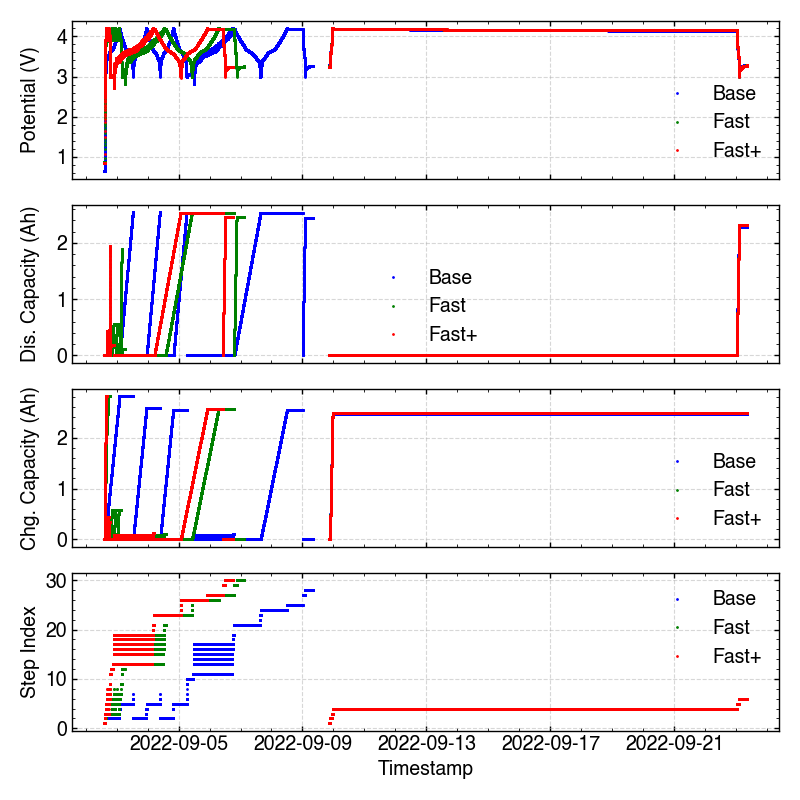

In [5]:
fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot
axs[0].plot(df1['Timestamp'], df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(df3['Timestamp'], df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(df4['Timestamp'], df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(df1['Timestamp'], df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(df3['Timestamp'], df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(df4['Timestamp'], df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(df1['Timestamp'], df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(df3['Timestamp'], df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(df4['Timestamp'], df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(df1['Timestamp'], df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(df3['Timestamp'], df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(df4['Timestamp'], df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()


# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()



In [6]:
# Define the step indices for the HPPC sequence
si1_hppc = [11, 12, 13, 14, 15, 16, 17]
si2_hppc = [13, 14, 15, 16, 17, 18, 19]
si3_hppc = [13, 14, 15, 16, 17, 18, 19]


In [7]:
# Subset df1, df3, and df4 using si1_hppc, si2_hppc, and si3_hppc to filter on 'Step Index'
subset_df1 = df1[df1['Step Index'].isin(si1_hppc)]
subset_df3 = df3[df3['Step Index'].isin(si2_hppc)]
subset_df4 = df4[df4['Step Index'].isin(si3_hppc)]

subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
subset_df4['Time (s)'] = (subset_df4['Timestamp'] - subset_df4['Timestamp'].iloc[0]).dt.total_seconds()

# Define a 0.1s grid for interpolation
time_grid = np.arange(0, max(subset_df1['Time (s)'].max(), subset_df3['Time (s)'].max(), subset_df4['Time (s)'].max()), 0.1)

# Interpolate for subset_df1
interp_voltage1 = interp1d(subset_df1['Time (s)'], subset_df1['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current1 = interp1d(subset_df1['Time (s)'], subset_df1['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp1 = time_grid
voltage_interp1 = interp_voltage1(time_interp1)
current_interp1 = interp_current1(time_interp1)

# Interpolate for subset_df3
interp_voltage3 = interp1d(subset_df3['Time (s)'], subset_df3['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current3 = interp1d(subset_df3['Time (s)'], subset_df3['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp3 = time_grid
voltage_interp3 = interp_voltage3(time_interp3)
current_interp3 = interp_current3(time_interp3)

# Interpolate for subset_df4
interp_voltage4 = interp1d(subset_df4['Time (s)'], subset_df4['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current4 = interp1d(subset_df4['Time (s)'], subset_df4['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp4 = time_grid
voltage_interp4 = interp_voltage4(time_interp4)
current_interp4 = interp_current4(time_interp4)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_60136/1429211087.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_60136/1429211087.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T

# Resistance

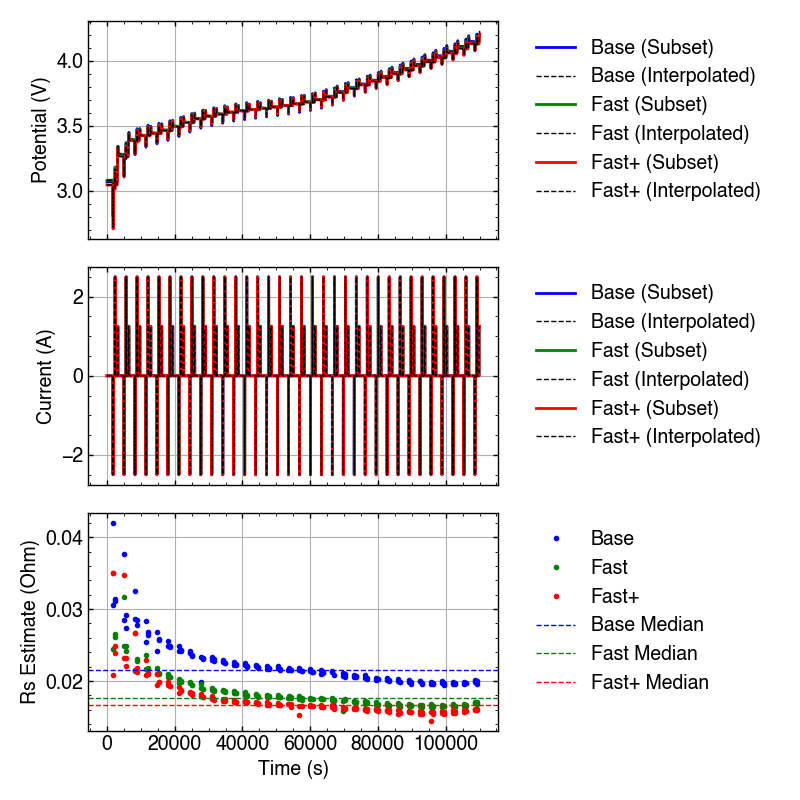

In [8]:
def calculate_resistance_estimates(Vmeas, Imeas):

    den = - (Imeas[0:-2] - Imeas[1:-1])
    num = Vmeas[1:-1] - Vmeas[0:-2]
    idx = np.where(np.abs(den) > 1.5)[0]
    Rs_estimate = num[idx]/den[idx]

    return Rs_estimate, idx

Rs_estimate1, idx1 = calculate_resistance_estimates(subset_df1['Potential (V)'].values, subset_df1['Current (A)'].values)
Rs_estimate3, idx3 = calculate_resistance_estimates(subset_df3['Potential (V)'].values, subset_df3['Current (A)'].values)
Rs_estimate4, idx4 = calculate_resistance_estimates(subset_df4['Potential (V)'].values, subset_df4['Current (A)'].values)

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axs[0].plot(subset_df1['Time (s)'], subset_df1['Potential (V)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[0].plot(time_interp1, voltage_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df3['Time (s)'], subset_df3['Potential (V)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[0].plot(time_interp3, voltage_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df4['Time (s)'], subset_df4['Potential (V)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[0].plot(time_interp4, voltage_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].set_ylabel('Potential (V)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Second subplot for Current
axs[1].plot(subset_df1['Time (s)'], subset_df1['Current (A)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[1].plot(time_interp1, current_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df3['Time (s)'], subset_df3['Current (A)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[1].plot(time_interp3, current_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df4['Time (s)'], subset_df4['Current (A)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[1].plot(time_interp4, current_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].set_ylabel('Current (A)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

axs[2].plot(subset_df1['Time (s)'].iloc[idx1], Rs_estimate1, label='Base', color='blue', marker='o', markersize=3, linestyle='None')
axs[2].plot(subset_df3['Time (s)'].iloc[idx3], Rs_estimate3, label='Fast', color='green', marker='o', markersize=3, linestyle='None')
axs[2].plot(subset_df4['Time (s)'].iloc[idx4], Rs_estimate4, label='Fast+', color='red', marker='o', markersize=3, linestyle='None')
axs[2].axhline(np.nanmedian(Rs_estimate1), color='blue', linestyle='--', linewidth=1, label='Base Median')
axs[2].axhline(np.nanmedian(Rs_estimate3), color='green', linestyle='--', linewidth=1, label='Fast Median')
axs[2].axhline(np.nanmedian(Rs_estimate4), color='red', linestyle='--', linewidth=1, label='Fast+ Median')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Rs Estimate (Ohm)')
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Manually extract the capacities from inspecting the plots

In [9]:
f1_capd1 = 2.527
f2_capd1 = 2.540
f3_capd1 = 2.536
f1_capd2 = 2.445
f2_capd2 = 2.461
f3_capd2 = 2.461
f1_capd3 = 2.275
f2_capd3 = 2.315
f3_capd3 = 2.318


# Summarize the results

In [10]:
data = {
    'Q1 [Ah]': [f1_capd1, f2_capd1, f3_capd1],
    'Q2 [Ah]': [f1_capd2, f2_capd2, f3_capd2],
    'Q3 [Ah]': [f1_capd3, f2_capd3, f3_capd3],
    'Rs [Ohms]': [np.nanmedian(Rs_estimate1), np.nanmedian(Rs_estimate3), np.nanmedian(Rs_estimate4)]
}
labels = ['Base', 'Fast', 'Fast+']

df_summary = pd.DataFrame(data, index=labels)
df_summary

,Q1 [Ah],Q2 [Ah],Q3 [Ah],Rs [Ohms]
Base,2.527,2.445,2.275,0.021465
Fast,2.540,2.461,2.315,0.017706
Fast+,2.536,2.461,2.318,0.016636


# Now take a closer look at all of the data

Including the cycling data!

In [11]:
expt1, df1 = fetch_experimental_data(152064, to_include_cycling=True)
expt3, df3 = fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = fetch_experimental_data(152098, to_include_cycling=True)

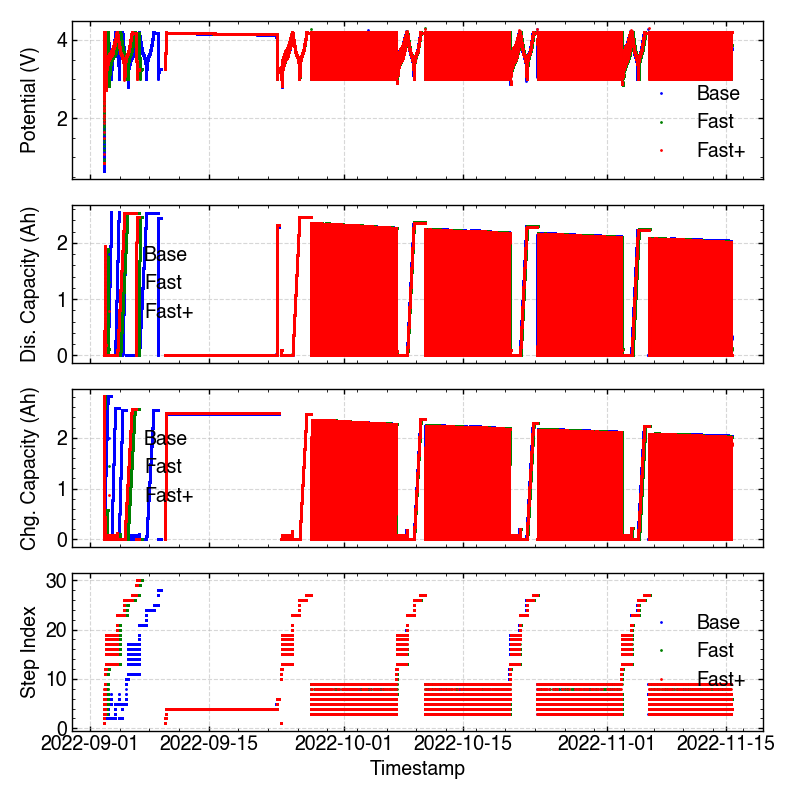

In [12]:
fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot
axs[0].plot(df1['Timestamp'], df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(df3['Timestamp'], df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(df4['Timestamp'], df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(df1['Timestamp'], df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(df3['Timestamp'], df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(df4['Timestamp'], df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(df1['Timestamp'], df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(df3['Timestamp'], df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(df4['Timestamp'], df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(df1['Timestamp'], df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(df3['Timestamp'], df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(df4['Timestamp'], df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()


# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()


# Cycle life

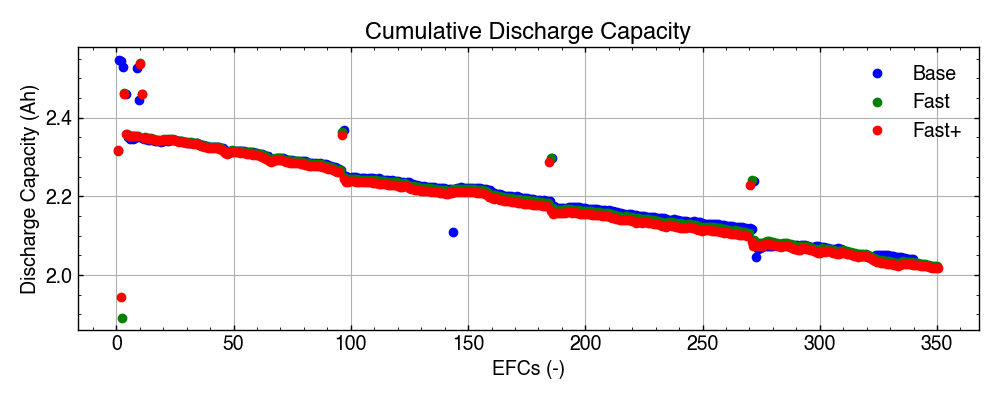

In [13]:
NOM_CAP = 2.5

df1_agg = df1.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()
df3_agg = df3.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()
df4_agg = df4.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()

df1_agg_cumsum = df1_agg.cumsum()/NOM_CAP
df3_agg_cumsum = df3_agg.cumsum()/NOM_CAP
df4_agg_cumsum = df4_agg.cumsum()/NOM_CAP

df1_agg[df1_agg.values < 1] = np.nan
df3_agg[df3_agg.values < 1] = np.nan
df4_agg[df4_agg.values < 1] = np.nan

fig, axs = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# Aggregate and plot for df1
axs.plot(df1_agg_cumsum.values, df1_agg.values, label='Base', color='blue', marker='o', linestyle='')
axs.plot(df3_agg_cumsum.values, df3_agg.values, label='Fast', color='green', marker='o', linestyle='')
axs.plot(df4_agg_cumsum.values, df4_agg.values, label='Fast+', color='red', marker='o', linestyle='')
axs.set_ylabel('Discharge Capacity (Ah)')
axs.set_xlabel('EFCs (-)')
axs.set_title('Cumulative Discharge Capacity')
axs.grid(True)
axs.legend()

plt.tight_layout()
plt.show()

# Coulombic efficiency during formation

              Charge Capacity (Ah)  Discharge Capacity (Ah)  \
Cycle Number                                                  
1                         2.814124                 2.546351   
2                         2.578596                 2.544815   
3                         2.554039                 2.529850   

              Coulombic Efficiency  
Cycle Number                        
1                         0.904847  
2                         0.986900  
3                         0.990529  


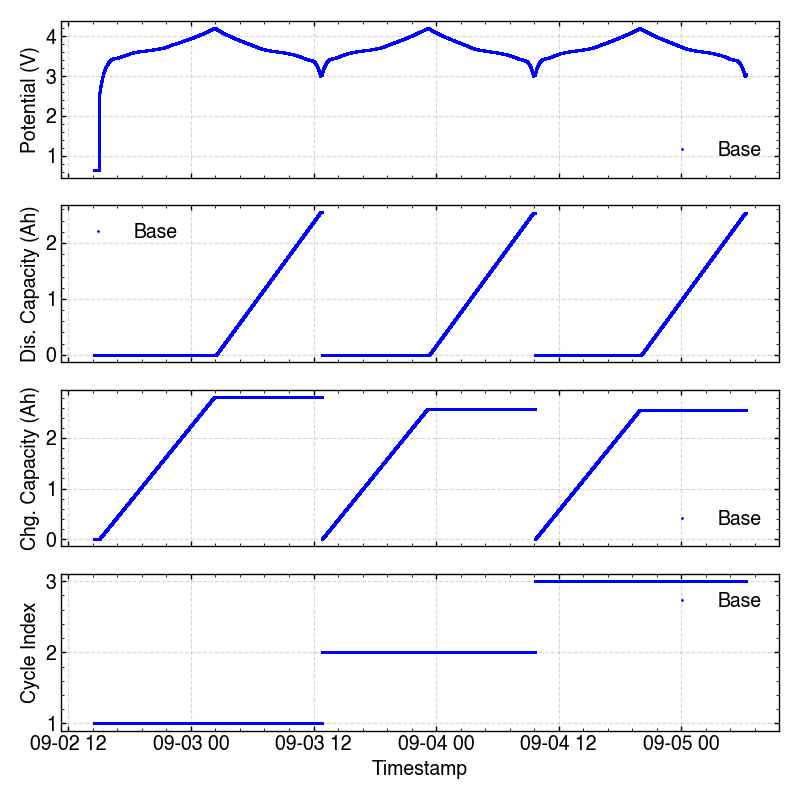

In [14]:
df1lim = df1[df1['Cycle Number'] <= 3]
df1lim = df1lim[df1lim['Timestamp'] < '2022-09-06 00:00:00']

df1lim_agg = df1lim.groupby('Cycle Number').agg({'Charge Capacity (Ah)': 'max', 'Discharge Capacity (Ah)': 'max'})
df1lim_agg['Coulombic Efficiency'] = df1lim_agg['Discharge Capacity (Ah)'] / df1lim_agg['Charge Capacity (Ah)']
print(df1lim_agg)

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot: Potential (V) vs. Timestamp
axs[0].plot(df1lim['Timestamp'], df1lim['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot: Discharge Capacity (Ah) vs. Timestamp
axs[1].plot(df1lim['Timestamp'], df1lim['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot: Charge Capacity (Ah) vs. Timestamp
axs[2].plot(df1lim['Timestamp'], df1lim['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot: Step Index vs. Timestamp
axs[3].plot(df1lim['Timestamp'], df1lim['Cycle Number'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Cycle Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

# Expansion Data

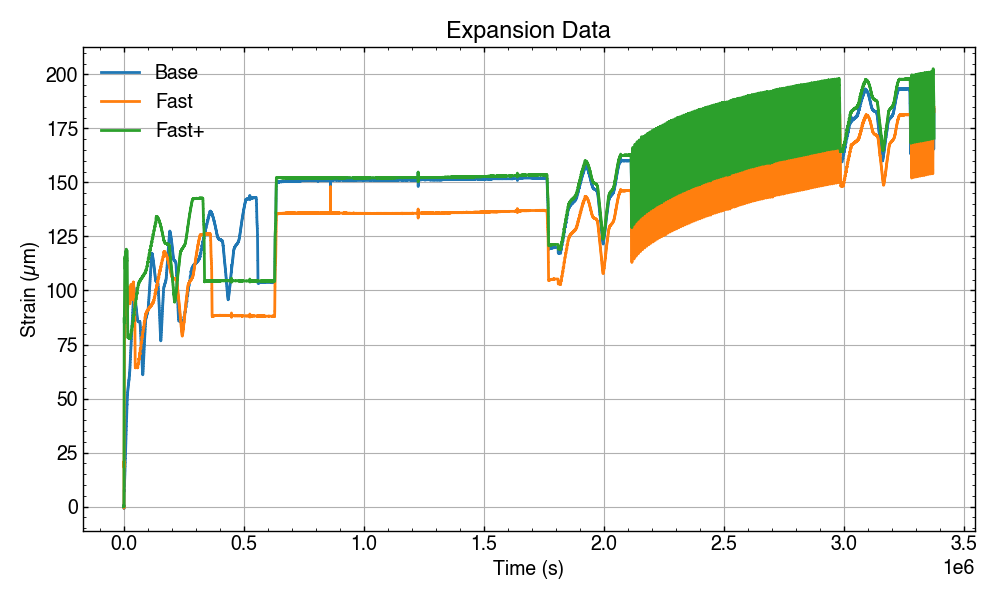

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(expt1['daq_time'], expt1['daq_strain'], label='Base')
ax.plot(expt3['daq_time'], expt3['daq_strain'], label='Fast')
ax.plot(expt4['daq_time'], expt4['daq_strain'], label='Fast+')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain (µm)')
ax.set_title('Expansion Data')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Run the sims!!

In [86]:
def interpolate_raw_data(t, y, dt):
    """
    Interpolates raw data to a specified time step.
    Parameters:
    ----------
    t: time vector
    y: data vector
    dt: time step for interpolation
    Returns:
    ----------
    t_interp: interpolated time vector
    y_interp: interpolated data vector
    """
    # Create interpolation function for voltage data

    t_interp = np.arange(t.min(), t.max(), dt)
    y_interp = np.interp(t_interp, t, y)

    return t_interp, y_interp

dt_data_interp = 5.0

t_interp1, i_interp1 = interpolate_raw_data(expt1['arbin_time'], expt1['arbin_current'], dt_data_interp)
t_interp3, i_interp3 = interpolate_raw_data(expt3['arbin_time'], expt3['arbin_current'], dt_data_interp)
t_interp4, i_interp4 = interpolate_raw_data(expt4['arbin_time'], expt4['arbin_current'], dt_data_interp)


In [95]:
diff_vc1 = 1.48e-18
diff_ec1 = 6.21e-20

diff_vc2 = 1.23e-15
diff_ec2 = 2.25e-20

diff_vc3 = 1.406e-14
diff_ec3 = 4.43e-20 

diff_ec = 4.2e-20
diff_vc = 6.6e-18 # For VC

gamma_kappa = 3367


df_sim1s = run_sim('base', diff_ec1, diff_vc1, gamma_kappa, dt=1, to_simulate_form_aging=False)
df_sim2s = run_sim('fast', diff_ec2, diff_vc2, gamma_kappa, dt=1, to_simulate_form_aging=False)
df_sim3s = run_sim('fast+', diff_ec3, diff_vc3, gamma_kappa, dt=1, to_simulate_form_aging=False)

# df_sim1 = run_sim('base', diff_ec1, diff_vc1, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp1, to_simulate_form_aging=True)
# df_sim2 = run_sim('fast', diff_ec2, diff_vc2, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp3, to_simulate_form_aging=True)
# df_sim3 = run_sim('fast+', diff_ec3, diff_vc3, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp4, to_simulate_form_aging=True)

df_sim1 = run_sim('base', diff_ec1, diff_vc1, gamma_kappa, dt=1, to_simulate_form_aging=True)
df_sim2 = run_sim('fast', diff_ec2, diff_vc2, gamma_kappa, dt=1, to_simulate_form_aging=True)
df_sim3 = run_sim('fast+', diff_ec3, diff_vc3, gamma_kappa, dt=1, to_simulate_form_aging=True)

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.0V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.0V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0

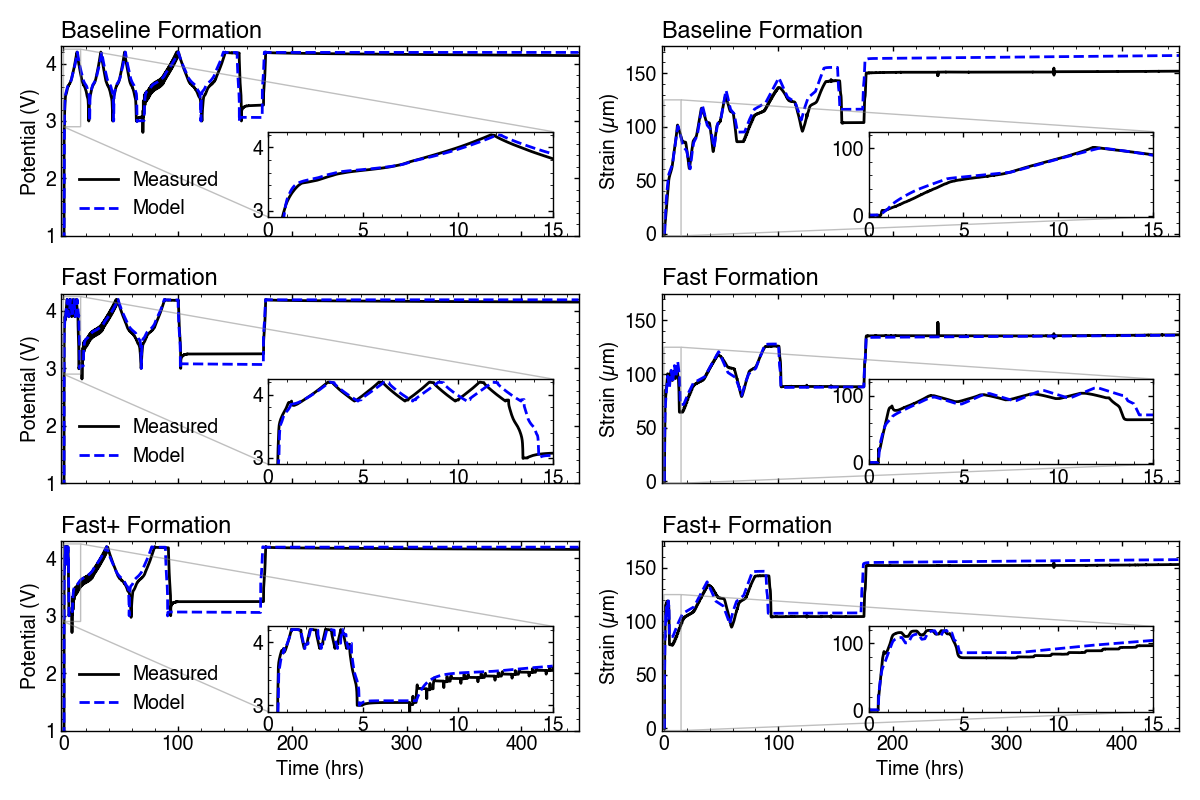

In [96]:
ylim_voltage = (1, 4.3)
ylim_strain = (-2, 175)
ylim_strain_reduced = (-2, 125)

fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

axs[0,0].set_title('Baseline Formation', loc='left')
axs[0,0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Measured', color='k')
# axs[0,0].plot(expt2['arbin_time']/3600, expt2['arbin_voltage'], label='Measured 2', color='gray')
axs[0,0].plot(df_sim1['t']/3600, df_sim1['vt'], label='Model', color='blue', ls='--')
axs[0,0].grid(False)
axs[0,0].legend(loc='lower left')
axs[0,0].set_ylabel('Potential (V)')
axs[0,0].set_ylim(ylim_voltage)

axs[1,0].set_title('Fast Formation', loc='left')
axs[1,0].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Measured', color='k')
axs[1,0].plot(df_sim2['t']/3600, df_sim2['vt'], label='Model', color='blue', ls='--')
axs[1,0].grid(False)
axs[1,0].legend(loc='lower left')
axs[1,0].set_ylabel('Potential (V)')
axs[1,0].set_ylim(ylim_voltage)

axs[2,0].set_title('Fast+ Formation', loc='left')
axs[2,0].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Measured', color='k')
axs[2,0].plot(df_sim3['t']/3600, df_sim3['vt'], label='Model', color='blue', ls='--')
axs[2,0].set_ylabel('Potential (V)')
axs[2,0].legend(loc='lower left')
axs[2,0].grid(False)
axs[2,0].set_ylim(ylim_voltage)

axs[2,0].set_xlim((-0.1, 600))
axs[2,0].set_xlabel('Time (hrs)')

# Second subplot: Strain vs. Time
axs[0,1].set_title('Baseline Formation', loc='left')
axs[0,1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Measured 1', color='k')
# axs[0,1].plot(expt2['daq_time']/3600, expt2['daq_strain'], label='Measured 2', color='gray')
axs[0,1].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, label='Model', color='blue', ls='--')
axs[0,1].grid(False)
axs[0,1].set_ylabel('Strain (µm)')
axs[0,1].set_ylim(ylim_strain)

axs[1,1].set_title('Fast Formation', loc='left')
axs[1,1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Measured', color='k')
axs[1,1].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, label='Model', color='blue', ls='--')
axs[1,1].grid(False)
axs[1,1].set_ylabel('Strain (µm)')
axs[1,1].set_ylim(ylim_strain)

axs[2,1].set_title('Fast+ Formation', loc='left')
axs[2,1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Measured', color='k')
axs[2,1].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, label='Model', color='blue', ls='--')
axs[2,1].set_ylabel('Strain (µm)')
axs[2,1].grid(False)
axs[2,1].set_xlabel('Time (hrs)')
axs[2,1].set_ylim(ylim_strain)

axs[2,1].set_xlim((-2, 450))

# Create insets for each subplot
axins00 = axs[0,0].inset_axes([0.4, 0.1, 0.55, 0.45])
axins10 = axs[1,0].inset_axes([0.4, 0.1, 0.55, 0.45])
axins20 = axs[2,0].inset_axes([0.4, 0.1, 0.55, 0.45])
axins01 = axs[0,1].inset_axes([0.4, 0.1, 0.55, 0.45])
axins11 = axs[1,1].inset_axes([0.4, 0.1, 0.55, 0.45])
axins21 = axs[2,1].inset_axes([0.4, 0.1, 0.55, 0.45])

# Plot data in insets
axins00.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline (Cell 1)', color='k')
# axins00.plot(expt2['arbin_time']/3600, expt2['arbin_voltage'], label='Baseline (Cell 2)', color='gray')
axins00.plot(df_sim1['t']/3600, df_sim1['vt'], label='Base Simulation', color='blue', ls='--')

axins10.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast', color='k')
axins10.plot(df_sim2['t']/3600, df_sim2['vt'], label='Fast Simulation', color='blue', ls='--')

axins20.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+', color='k')
axins20.plot(df_sim3['t']/3600, df_sim3['vt'], label='Fast+ Simulation', color='blue', ls='--')

axins01.plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline (Cell 1)', color='k')
# axins01.plot(expt2['daq_time']/3600, expt2['daq_strain'], label='Baseline (Cell 2)', color='gray')
axins01.plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, label='Base Simulation', color='blue', ls='--')

axins11.plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='k')
axins11.plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, label='Fast Simulation', color='blue', ls='--')

axins21.plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='k')
axins21.plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, label='Fast+ Simulation', color='blue', ls='--')

# Set the limits for all insets (first 15 hours)
for ax in [axins00, axins10, axins20, axins01, axins11, axins21]:
    ax.set_xlim(0, 15)
    ax.grid(False)

# Set y-limits for voltage insets
for ax in [axins00, axins10, axins20]:
    ax.set_ylim((2.9, 4.25))

# Set y-limits for strain insets 
for ax in [axins01, axins11, axins21]:
    ax.set_ylim(ylim_strain_reduced)

# Add indication boxes
for i in range(3):
    axs[i,0].indicate_inset_zoom(axins00 if i==0 else axins10 if i==1 else axins20)
    axs[i,1].indicate_inset_zoom(axins01 if i==0 else axins11 if i==1 else axins21)

plt.tight_layout()
plt.show()

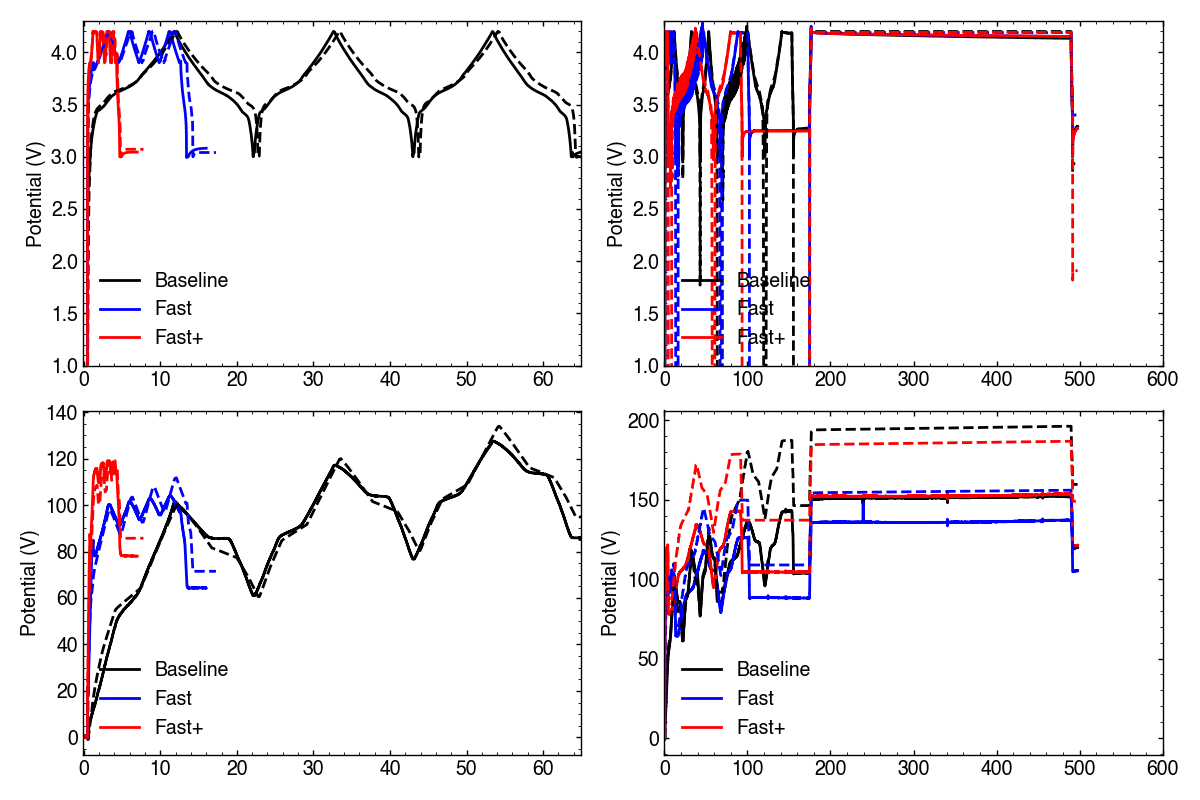

In [94]:
ylim_voltage = (1, 4.3)
ylim_strain = (-2, 175)
ylim_strain_reduced = (-2, 125)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

axs[0,0].plot(expt1s['arbin_time']/3600, expt1s['arbin_voltage'], label='Baseline', color='k')
axs[0,0].plot(expt3s['arbin_time']/3600, expt3s['arbin_voltage'], label='Fast', color='b')
axs[0,0].plot(expt4s['arbin_time']/3600, expt4s['arbin_voltage'], label='Fast+', color='r')
axs[0,0].plot(df_sim1s['t']/3600, df_sim1s['vt'], label='', color='k', ls='--')
axs[0,0].plot(df_sim2s['t']/3600, df_sim2s['vt'], label='', color='blue', ls='--')
axs[0,0].plot(df_sim3s['t']/3600, df_sim3s['vt'], label='', color='r', ls='--')
axs[0,0].grid(False)
axs[0,0].legend(loc='lower left')
axs[0,0].set_ylabel('Potential (V)')
axs[0,0].set_ylim(ylim_voltage)
axs[0,0].set_xlim((-0.1, 65))

axs[1,0].plot(expt1s['daq_time']/3600, expt1s['daq_strain'], label='Baseline', color='k')
axs[1,0].plot(expt3s['daq_time']/3600, expt3s['daq_strain'], label='Fast', color='b')
axs[1,0].plot(expt4s['daq_time']/3600, expt4s['daq_strain'], label='Fast+', color='r')
axs[1,0].plot(df_sim1s['t']/3600, df_sim1s['expansion']*1e6, label='', color='k', ls='--')
axs[1,0].plot(df_sim2s['t']/3600, df_sim2s['expansion']*1e6, label='', color='b', ls='--')
axs[1,0].plot(df_sim3s['t']/3600, df_sim3s['expansion']*1e6, label='', color='r', ls='--')
axs[1,0].grid(False)
axs[1,0].legend(loc='lower left')
axs[1,0].set_ylabel('Potential (V)')
axs[1,0].set_xlim((-0.1, 65))

axs[0,1].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline', color='k')
axs[0,1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast', color='b')
axs[0,1].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+', color='r')
axs[0,1].plot(df_sim1['t']/3600, df_sim1['vt'], label='', color='k', ls='--')
axs[0,1].plot(df_sim2['t']/3600, df_sim2['vt'], label='', color='blue', ls='--')
axs[0,1].plot(df_sim3['t']/3600, df_sim3['vt'], label='', color='r', ls='--')
axs[0,1].grid(False)
axs[0,1].legend(loc='lower left')
axs[0,1].set_ylabel('Potential (V)')
axs[0,1].set_ylim(ylim_voltage)
axs[0,1].set_xlim((-0.1, 600))

axs[1,1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline', color='k')
axs[1,1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='b')
axs[1,1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='r')
axs[1,1].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, label='', color='k', ls='--')
axs[1,1].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, label='', color='b', ls='--')
axs[1,1].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, label='', color='r', ls='--')
axs[1,1].grid(False)
axs[1,1].legend(loc='lower left')
axs[1,1].set_ylabel('Potential (V)')
axs[1,1].set_xlim((-0.1, 600))


plt.tight_layout()
plt.show()

In [17]:
from src import cellsim as cellsim

%autoreload
Ichg = 2.5/10  # A
Idch = -2.5/10 # A
Icv = 2.5/20   # A

vmax = 4.2
vmin = 3.0

cell = cellsim.Cell()
cell.load_config('params/default.yaml')
tag = cell.get_tag()

# sim = cellsim.Simulation(cell, 520*3600)
sim1 = cellsim.Simulation(cell, 70*24*3600)

# Formation
sim1.run_rest(1, rest_time_hrs=0.5)
sim1.run_chg_cccv(2, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(2, rest_time_hrs=1/6) 
sim1.run_dch_cccv(2, -2.5/10, -2.5/10, 3.0)
sim1.run_rest(2, rest_time_hrs=1/6) 
sim1.run_chg_cccv(3, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(3, rest_time_hrs=1/6) 
sim1.run_dch_cccv(3, -2.5/10, -2.5/10, 3.0)
sim1.run_rest(3, rest_time_hrs=1/6) 
sim1.run_chg_cccv(4, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(4, rest_time_hrs=1/6) 
sim1.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
sim1.run_rest(4, rest_time_hrs=1/6) 
sim1.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
sim1.run_rest(4, rest_time_hrs=6)

# RPT
sim1.run_chg_cccv(5, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(5, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(6, +2.5/20, Icv, vmax)
sim1.run_rest(6, rest_time_hrs=12)
sim1.run_dch_cccv(6, -2.5/2, -2.5/2, vmin)
sim1.run_rest(6, rest_time_hrs=20)

# Formation Aging
sim1.run_chg_cccv(7, 2.5/2, 0.05, vmax)
sim1.run_rest(7, rest_time_hrs=13*24) # 13 days rest
sim1.run_dch_cccv(7, -2.5/2, -2.5/2, vmin)
sim1.run_rest(7, rest_time_hrs=12) # 12 hours rest

# RPT
sim1.run_chg_cccv(8, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(8, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(8, +2.5/20, Icv, vmax)
sim1.run_rest(    9, rest_time_hrs=12)
sim1.run_dch_cccv(9, -2.5/2, -2.5/2, vmin)

# Cycling
cycles_to_rpt = 100
for i in np.arange(10, 10 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(111, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(111, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(111, +2.5/20, Icv, vmax)
sim1.run_rest(112, rest_time_hrs=12)
sim1.run_dch_cccv(112, -2.5/2, -2.5/2, vmin)

# Cycling
for i in np.arange(113, 113 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(214, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(214, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(215, +2.5/20, Icv, vmax)
sim1.run_rest(    215, rest_time_hrs=12)
sim1.run_dch_cccv(215, -2.5/2, -2.5/2, vmin)

# Cycling
for i in np.arange(216, 216 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(317, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(317, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(318, +2.5/20, Icv, vmax)
sim1.run_rest(    318, rest_time_hrs=12)
sim1.run_dch_cccv(318, -2.5/2, -2.5/2, vmin)

df_sim1 = sim1.get_results()

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.0V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.0V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Charge to 4.2V...
Running Cyc6: Rest for 12 hours...
Running Cyc6: Discharge to 3.0V...
Running Cyc6: Rest for 20 hours...
Running Cyc7: Charge to 4.2V...
Running Cyc7: Rest for 312 hours...
Running Cyc7: Discharge to 3.0V...
Running Cyc7: Rest for 12 hours...
Running Cyc8: Charge to 4.2V...
Running 

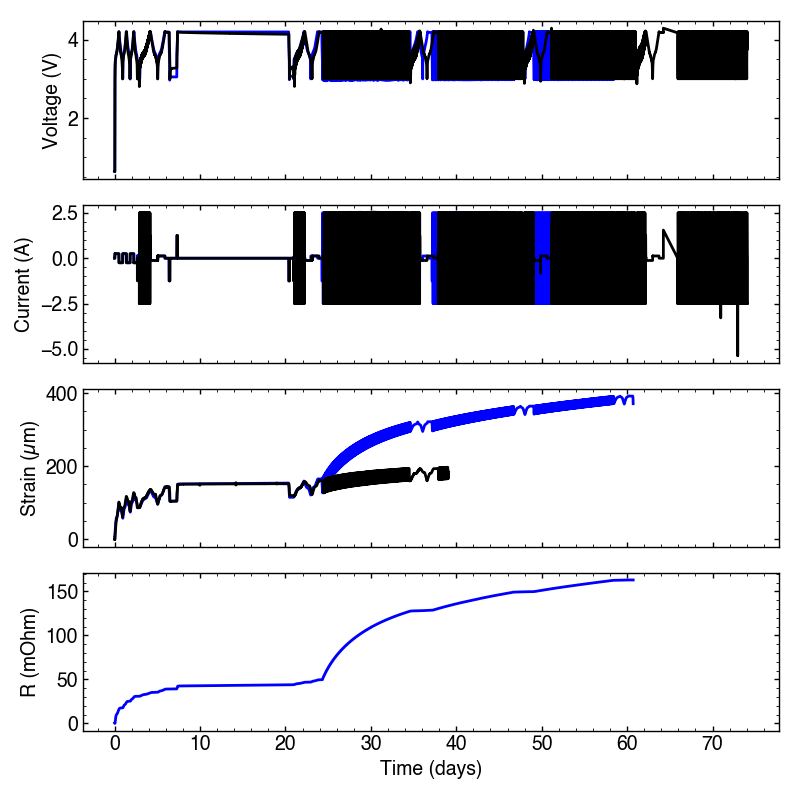

In [18]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot: Time vs Voltage
axs[0].plot(df_sim1['t']/3600/24, df_sim1['vt'], label='Simulated', color='blue')
axs[0].plot(expt1['arbin_time']/3600/24, expt1['arbin_voltage'], label='Measured', color='black')
axs[0].set_ylabel('Voltage (V)')
axs[0].grid(False)

axs[1].plot(df_sim1['t']/3600/24, df_sim1['i_app'], label='Simulated', color='blue')
axs[1].plot(expt1['arbin_time']/3600/24, expt1['arbin_current'], label='Measured', color='black')
axs[1].set_ylabel('Current (A)')
axs[1].grid(False)

# Second subplot: Time vs Expansion
axs[2].plot(df_sim1['t']/3600/24, 1e6*df_sim1['expansion'], label='Simulated', color='blue')
axs[2].plot(expt1['daq_time']/3600/24, expt1['daq_strain'], label='Measured', color='black')
axs[2].set_ylabel('Strain (µm)')
axs[2].grid(False)

# Third subplot: Time vs R_sei
axs[3].plot(df_sim1['t']/3600/24, 1e3*df_sim1['R_sei'], label='Simulated R_sei', color='blue')
axs[3].set_xlabel('Time (days)')
axs[3].set_ylabel('R (mOhm)')
axs[3].grid(False)

plt.tight_layout()
plt.show()